In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)

c:\Users\Azrap\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Azrap\.cache\kagglehub\datasets\rjmanoj\credit-card-customer-churn-prediction\versions\1


In [5]:
import os

df=pd.read_csv(os.path.join(path,'Churn_Modelling.csv'))

In [6]:
df.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [7]:
df.drop(['RowNumber','Surname'],axis=1,inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop('CustomerId',axis=1,inplace=True)

In [10]:
df.columns=df.columns.str.lower().str.strip()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      10000 non-null  int64  
 1   geography        10000 non-null  str    
 2   gender           10000 non-null  str    
 3   age              10000 non-null  int64  
 4   tenure           10000 non-null  int64  
 5   balance          10000 non-null  float64
 6   numofproducts    10000 non-null  int64  
 7   hascrcard        10000 non-null  int64  
 8   isactivemember   10000 non-null  int64  
 9   estimatedsalary  10000 non-null  float64
 10  exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [12]:
cat_cols=[i for i in df.columns if df[i].dtypes=='str']
cat_cols

['geography', 'gender']

In [13]:
for i in cat_cols:
    print(df[i].unique())
    print()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

<StringArray>
['Female', 'Male']
Length: 2, dtype: str



In [14]:
# encoding gender column

df['gender']=df['gender'].map({
    'Female':1,
    'Male':0
})

In [15]:
df.isnull().sum()

creditscore        0
geography          0
gender             0
age                0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
exited             0
dtype: int64

In [16]:
df['tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [17]:
num_cols=[i for i in df.columns if df[i].dtypes!='str']
num_cols

['creditscore',
 'gender',
 'age',
 'tenure',
 'balance',
 'numofproducts',
 'hascrcard',
 'isactivemember',
 'estimatedsalary',
 'exited']

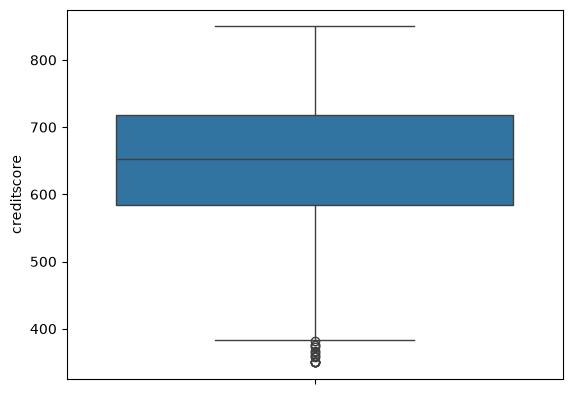

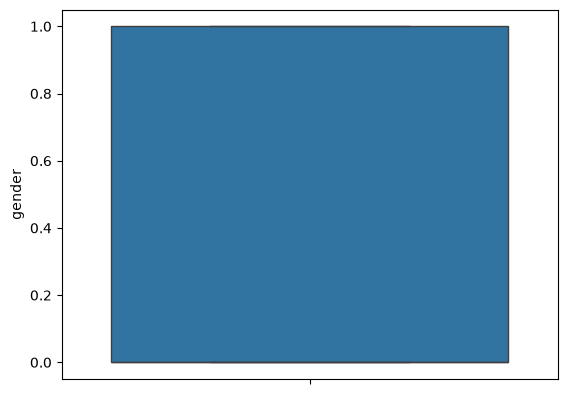

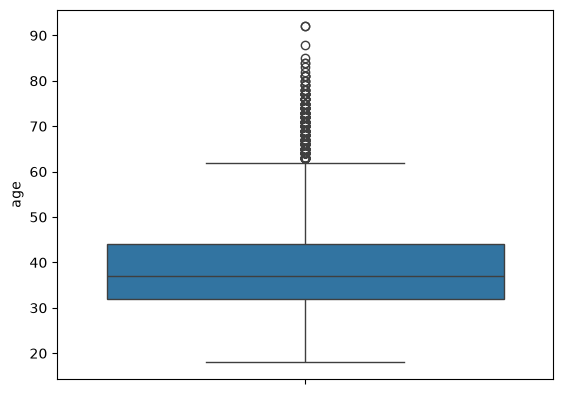

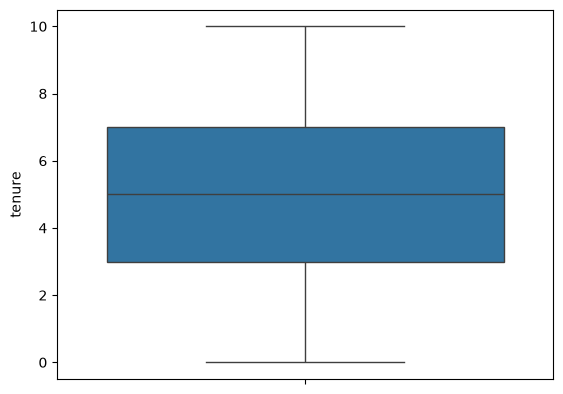

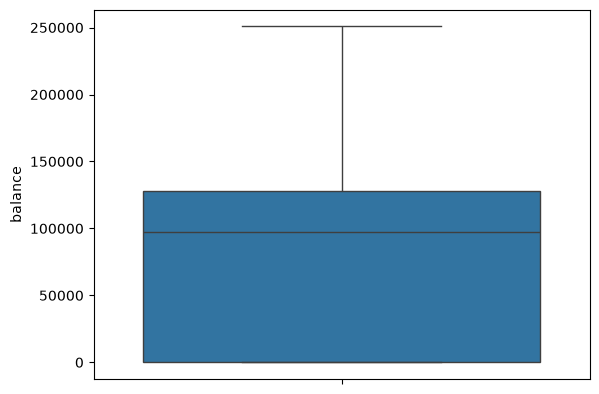

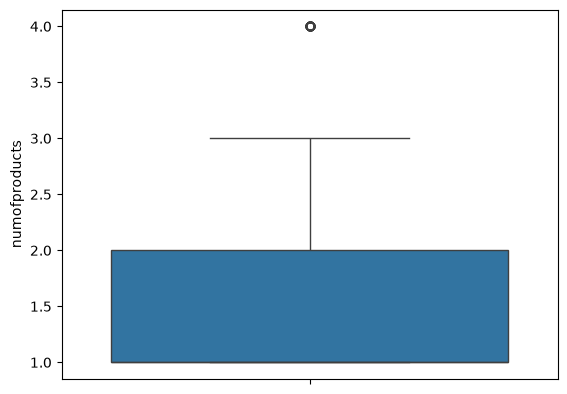

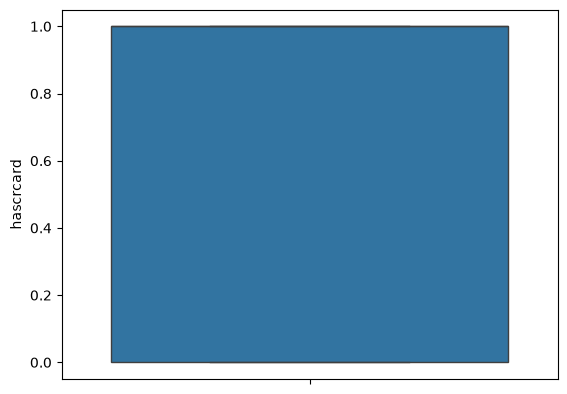

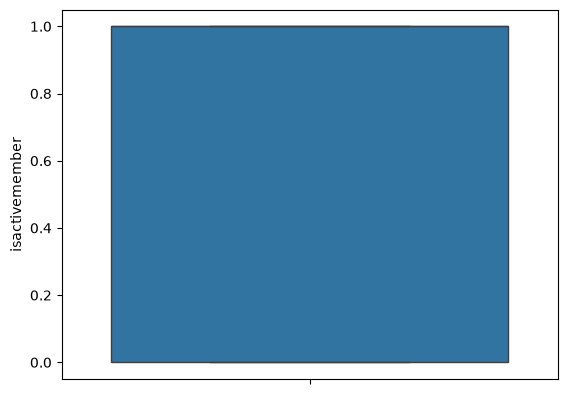

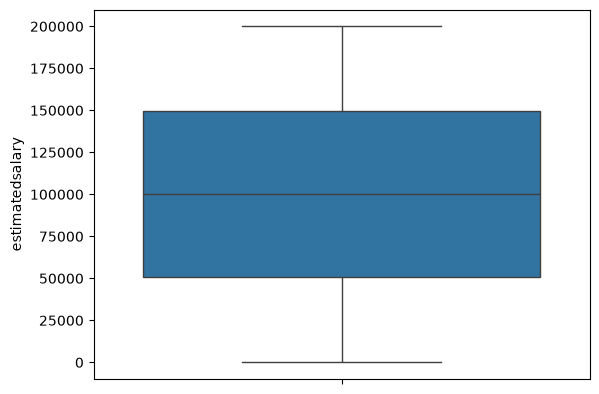

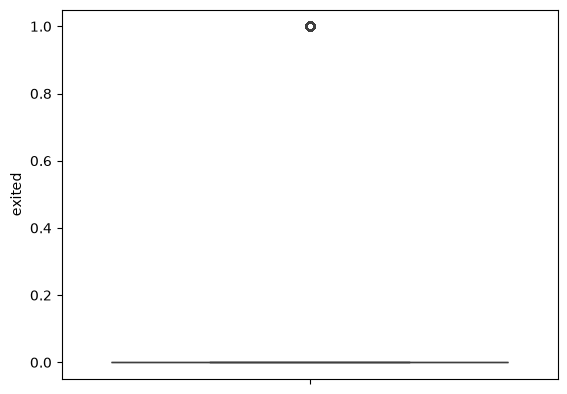

In [18]:
for i in num_cols:
    sns.boxplot(df[i])
    plt.show()
    

In [19]:
for i in num_cols:
    print(i)
    print(df[i].unique())
    print()

creditscore
[619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 56

In [20]:
# will create diffenret pipelines 

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ohe pipeline
ohe_pipeline=Pipeline([
    ("ohe",OneHotEncoder(handle_unknown='ignore'))
])
ohe_col=['geography']

#scaling
scale_pipeline=Pipeline([
    ("scaler",StandardScaler())
])
scale_col=['creditscore','age','tenure','balance','numofproducts']

normal_cols=['gender','hascrcard','isactivemember','exited']


preprocessor=ColumnTransformer([
    ("ohe_pipeline",ohe_pipeline,ohe_col),
    ("scaler",scale_pipeline,scale_col),
    ("passthrough","passthrough",normal_cols)
])

In [21]:
preprocessor

ColumnTransformer(transformers=[('ohe_pipeline',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['geography']),
                                ('scaler',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['creditscore', 'age', 'tenure', 'balance',
                                  'numofproducts']),
                                ('passthrough', 'passthrough',
                                 ['gender', 'hascrcard', 'isactivemember',
                                  'exited'])])

In [22]:
#split the data

X=df.drop('estimatedsalary',axis=1)
y=df['estimatedsalary']

In [23]:
df.shape

(10000, 11)

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
X_train.shape[1]

10

In [26]:
import sys
print(sys.executable)

c:\Users\Azrap\AppData\Local\Programs\Python\Python312\python.exe


In [27]:
import optree
print(optree.__version__)
print(optree.__file__)

0.20.0
c:\Users\Azrap\AppData\Local\Programs\Python\Python312\Lib\site-packages\optree\__init__.py


In [28]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [30]:
X_train_processed.shape

(8000, 12)

In [31]:
#ann model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

ann=Sequential([
    Dense(128,activation='relu',input_dim=X_train_processed.shape[1]),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='linear')
])

ann.compile(optimizer='adam',loss='mae',metrics=['mae'])



c:\Users\Azrap\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
y_train

9254    179093.26
1561    195978.86
1670     85891.02
6087    153080.40
6669     39488.04
          ...    
5734     69381.05
5191       706.50
5390     92220.12
860      97508.04
7270     53581.14
Name: estimatedsalary, Length: 8000, dtype: float64

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True

)

ann_history=ann.fit(X_train_processed,y_train,epochs=50,validation_data=(X_test_processed,y_test),verbose=1,callbacks=[early_stop])

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 95981.5078 - mae: 95981.5078 - val_loss: 76086.6406 - val_mae: 76086.6406
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56645.1250 - mae: 56645.1250 - val_loss: 52071.9609 - val_mae: 52071.9609
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51578.4102 - mae: 51578.4102 - val_loss: 51692.3633 - val_mae: 51692.3633
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 51240.9219 - mae: 51240.9219 - val_loss: 51400.0977 - val_mae: 51400.0977
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50971.7812 - mae: 50971.7812 - val_loss: 51130.2656 - val_mae: 51130.2656
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50741.5273 - mae: 50741.5273 - val_loss: 50935.4414 - val_mae: 50935.4414
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50509.6680 - mae: 50509.6680 - val_loss: 50742.2812 - val_mae: 50742.2812
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50

In [35]:
#evaluate_model

test_loss,test_mae=ann.evaluate(X_test_processed,y_test)

print(test_loss)
print(test_mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49936.2383 - mae: 49936.2383
49936.23828125
49936.23828125


In [37]:
import joblib

joblib.dump(preprocessor,'preprocessor.pkl')

['preprocessor.pkl']

In [38]:
ann.save('price_predictor.h5')

In [39]:
X_train

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,exited
9254,686,France,0,32,6,0.00,2,1,1,0
1561,632,Germany,0,42,4,119624.60,2,1,1,0
1670,559,Spain,0,24,3,114739.92,1,1,0,1
6087,561,France,1,27,9,135637.00,1,1,0,1
6669,517,France,0,56,9,142147.32,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
5734,768,France,0,54,8,69712.74,1,1,1,0
5191,682,France,1,58,1,0.00,1,1,1,0
5390,735,France,1,38,1,0.00,3,0,0,1
860,667,France,0,43,8,190227.46,1,1,0,1


In [34]:
df.head(2)

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,1,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58,0
